# Transfer Learing for sequences: BERT and BERT Variants
In this notebook, we will learn how to use a foundational model like BERT for transfer learning using PyTorch. The note book is broken into multiple sections, as follows:
- Using 1D convolutional architectures, pretrained
- Description of the BERT Model and loading
- BERT Pre-processing on the 20 newsgroups data
- TinyBERT Example, for using laptops and lighter weight hardware

Be sure to use the Table of Contents in Jupyter notebook for navigation. `View > Table of Contents`

_________
<a id="install"></a>
# Installing Torch and Dependencies for BERT / VGGish
We will use hugging face transformers to load/deply VGGish and BERT. I used the following for installation:
```
pip install datasets
pip install resampy
pip install soundfile
```
Some dependencies might be needed for using TinyBERT on your system. You know your system best--so use your best judgement when installing. 
Since hugging face is commonly built for PyTorch, and many Tensorflow models have PyTorch eeights available, we will try to use HuggingFace when possible.

In [5]:
# we are also going to use hugging face, which requires the use of tensorflow
# NOTE: The version of numpy used is NOT the latest, I had to downgrade for compatibility
import torch
print(f"Torch: {torch.__version__}")

import numpy as np
print(f"NumPy: {np.__version__}")

from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns

Torch: 2.13.0
NumPy: 1.26.4


## VGG-ish Architecture
This is a convolutional architecture that processes and embeds audio files into fixed 128 dimensional features (one feature for each frame). Each frame processed in VGGish is about 1 second long (0.96 seconds) and can be used to embed audio for further downstream processing. Let's load the model here and look at the architecture.

In [2]:


# Load the PyTorch VGGish port directly from GitHub Hub
sound_model = torch.hub.load('harritaylor/torchvggish', 'vggish')
sound_model.eval()


Using cache found in /Users/eclarson/.cache/torch/hub/harritaylor_torchvggish_master


VGGish(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False

The architecture is quite simple. The `model.features` processes input audio (that has been processed into a Mel Spectrogram) and convolves multiple times. Then each remaining column is processed using the `model.embedding` to create a sequence of audio embeddings. We could further process those embeddings with 1D convolution, and global averaging to collapse to a single vector. Notice that there is not a flattening operation, the 2D convolution and pooling result in a large output matrix (3 dimensional). Then each frame (time segment) is processed with linear layers, resulting in a column of 128 features per frame.

 ![vggish](https://www.researchgate.net/publication/350575603/figure/fig15/AS:1008013452255239@1617340543389/Audiosets-VGGish-Convolution-Neural-Network-This-CNN-is-based-on-VGG-Audioset-team.png)

 The model here also can be given a filename, which it will read in the audio file, take the proper Mel Spectrogram, and then embed the audio. That is a great feature, as we do not need to write code for pre-processing the input audio files. 

(5, 128) (179, 128) (10, 128)


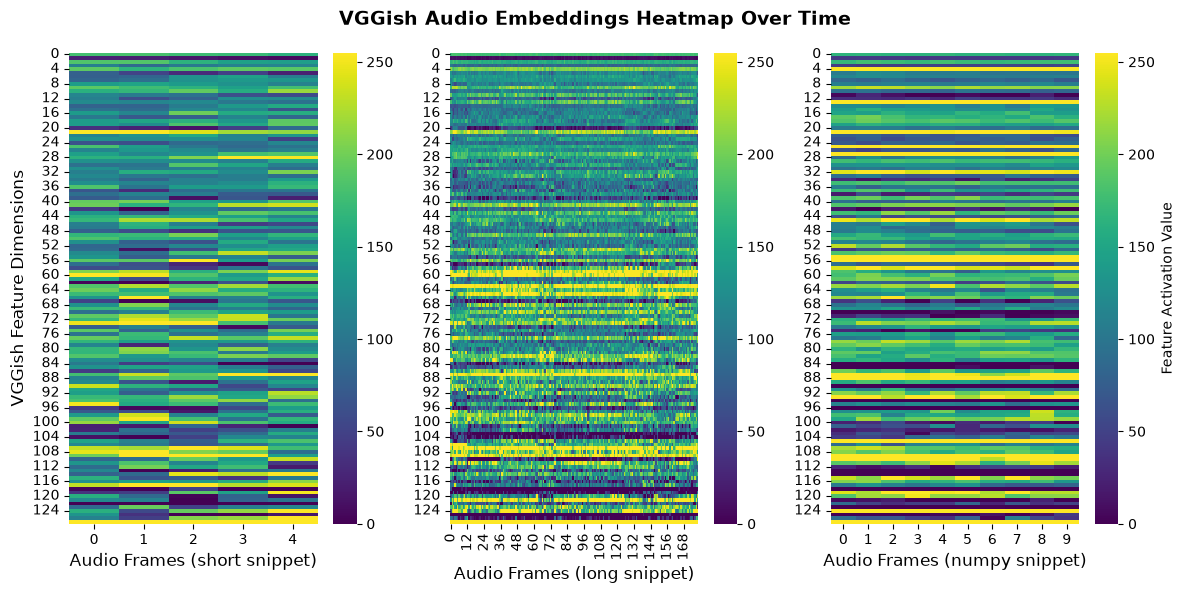

In [33]:
with torch.no_grad():
    embed_short = sound_model('large_data/short_audio.mp3').cpu().numpy()
    embed_long  = sound_model('large_data/long_audio.mp3').cpu().numpy()
    raw_waveform_np = np.random.randn(16000 * 10, 1).astype(np.float32)
    embed_simulated = sound_model(raw_waveform_np, fs=16000).cpu().numpy()
    
print(embed_short.shape, embed_long.shape, embed_simulated.shape)

plt.figure(figsize=(12, 6))


plt.subplot(1,3,1)
sns.heatmap(embed_short.T,cmap="viridis",robust=True)
plt.xlabel("Audio Frames (short snippet)", fontsize=12)
plt.ylabel("VGGish Feature Dimensions", fontsize=12)

plt.subplot(1,3,2)
sns.heatmap(embed_long.T, cmap="viridis",robust=True,)
plt.xlabel("Audio Frames (long snippet)", fontsize=12)

plt.subplot(1,3,3)
sns.heatmap(embed_simulated.T,cmap="viridis",robust=True,
    cbar_kws={"label": "Feature Activation Value"},
)
plt.xlabel("Audio Frames (numpy snippet)", fontsize=12)


plt.suptitle("VGGish Audio Embeddings Heatmap Over Time", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

In [27]:
import torch.nn as nn

class VGGishTransferLearningClassifier(nn.Module):
    def __init__(self, num_classes=10, conv_channels=64, kernel_size=3, hidden_dim=64):
        super(VGGishTransferLearningClassifier, self).__init__()
        
        # Load the backbone, 128-dimensional embedding peraudio frame
        self.vggish = torch.hub.load('harritaylor/torchvggish', 'vggish')
        
        # Freeze VGGish weights (only want to train the classification head)
        for param in self.vggish.parameters():
            param.requires_grad = False
            
        # Add a 1D Convolutional Layer across the time dimension
        # Input channels = 128 (VGGish embedding size)
        self.conv1d = nn.Conv1d(
            in_channels=128, out_channels=conv_channels, 
            kernel_size=kernel_size, padding="same"
        )
        self.relu = nn.ReLU()

        # the number of columns will be different for different length audio inputs
        # this operation will collapse it down
        # Global Average Pooling (collapses variable time lengths to 1)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Two Linear classification layers
        self.fc1 = nn.Linear(conv_channels, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x, sample_rate=None):
        # If x could be an audio file path or raw waveform tensor 
        # vggish processes it into [Time, 128]. 
        # For batching, input shape is already preprocessed: [Batch, Time, 128]
        
        # Extract VGGish features, [Time, 128]
        features = self.vggish(x, fs=sample_rate)
        # add batch dimension, [Batch, Time, 128]
        features = features.unsqueeze(0)
        # Transpose for Conv1D: [Batch, Time, 128] -> [Batch, 128, Time]
        features = features.transpose(1, 2)
        # Run 1D Convolution across time: [Batch, conv_channels, Time]
        out = self.conv1d(features)
        out = self.relu(out)
        # Collapse via Global Average Pooling, [Batch, conv_channels, 1]
        out = self.global_pool(out)
        #Flatten for dense layers: [Batch, conv_channels]
        out = out.squeeze(-1)
        
        # Pass through two Linear layers
        out = self.fc1(out)
        out = self.relu(out)
        logits = self.fc2(out)
        
        return logits

model = VGGishTransferLearningClassifier()
output = model('large_data/short_audio.mp3')

print(output.shape)

model

Using cache found in /Users/eclarson/.cache/torch/hub/harritaylor_torchvggish_master


torch.Size([1, 10])


VGGishTransferLearningClassifier(
  (vggish): VGGish(
    (features): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU(inplace=True)
      (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): ReLU(inplace=True)
      (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (12): ReLU(inplace=True)
      (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (14): ReLU(inplace=True)
     

In [28]:
# Alternatively, we can also just pass the audio file samples directly
# this is better when you load from the audio source and just want to 
# re-use the loaded samples. 
sample_rate=16000
duration_seconds = 5
raw_waveform_np = np.random.randn(sample_rate * duration_seconds,1).astype(np.float32)
print(raw_waveform_np.shape)

model(raw_waveform_np, sample_rate=sample_rate)

(80000, 1)


tensor([[  2.9062,  -7.5887,  15.5100,   9.8070,  14.5023,  -8.9313,  -1.8509,
         -12.0588,  -5.7543,   9.5794]], grad_fn=<AddmmBackward0>)

Now we can use the above classifier to train a directory of audio classification snippets, regardless of their length. This model only needs the sound snippets to be a bit longer than a second and it can embed them with the VGGish model, run a trainable 1D convolution, then flatten and classifer with a MLP style architecture. The labels are needed per audio file. This is also the way that Apple's sound classifier is trained on various smartphones. 

Now, let's change modes and move to text sequenc classification 

**[Back To Slides]**

_____
# A Brief Explanation of BERT
BERT stands for Bidirectional Encoder Representations from Transformers and it trains a modest sized transformer architecture in a few ways: 
- Next Sentence Prediction (NSP), should two sentences should logically follow each other?
- Masked Language Model (Masked LM), if some words are masked, can the model guess the masked words correctly based on the other words in the document.
- Two version exists: BERT-base (12 encoder layers) vs. BERT-large (24 encoder layers)
- Hugging face offers open source trained models for BERT that are accesisble using PyTorch: https://huggingface.co/google-bert/bert-base-uncased

**Current explanations are started from ChatGPT, then heavily manipulated to make more sense and add context.**

- **Overall Architecture**
  - Input Processing: Words are first tokenized and embedded using words embeddings. These embedding dimensions determine how many different aspects of language can be analyzed. The information does not need to be orthognal (practically) so there and many more aspects captured than dimensions.   
  - Encoder: Embeddings are fed into transformer layers. These layers are tasked with updating the word embeddings using context of the entire sequence. Many transformer layers are employed. Pre-trained weights in the encoder capture general linguistic patterns (e.g., syntax, semantics). During fine-tuning, the encoder layers are often partially or fully updated to adapt to the specific task.
  - Pooling Module: Determines how the encoder outputs are aggregated for the downstream task. This changes depending upon how transfer learning will be employed. For example:
    - (1) Entire Sequence Classification tasks: Use the [CLS] token embedding or a form of pooling that distills down the transformer outputs into a fixed size embedding. 
    - (2) Sequence labeling tasks (e.g., Named Entity Recognition): Use token embeddings directly.
    - (3) Text similarity tasks: Use embeddings from both sequences for comparison.
- **Input Processing**
  - To make text understandable to BERT, it converts the input into a fixed format:
    - Tokens: The text is split into subwords using the WordPiece tokenizer in BERT. This tokenization breaks down word stems, punctuation, and modifiers as spearate tokens. It also adds [CLS] and [SEP] tokens.  
    - Token Embeddings: Each token is mapped to a dense vector using an embedding matrix. The embedding size (output) for each token is 768 elements. This size is moderate relative to other LLMs (that might employ thousands of dimensions for the embedding output). 
    - Segment Embeddings: Different segments (e.g., sentence A vs. sentence B) are marked for tasks involving pairs of sentences. The utility of these segment embeddings is not fully understood, as the input to the segment can only be "A" or "B". In most cases, this embedding does not serve to improve performance except when using multi-lingual BERT (https://aclanthology.org/2022.lrec-1.152/).
    - Positional Embeddings: These are trained embeddings of dimension 768. These are added to token embeddings to encode token order in the sequence. As duscussed in lecture, transformers do not have a built-in notion of sequence order, so BERT adds these embeddings to represent token positions. 
    - The final input is the sum of these three embeddings.
  - A note on the CLS Token Representation: BERT introduces a special [CLS] token at the beginning of every input sequence and an ending [SEP] token to the end of each sequence.  After the encoder processes the sequence, the output embedding corresponding to the [CLS] token is treated as a holistic representation of the entire input. This [CLS] embedding is often passed through a task-specific pooling head for downstream tasks like sequence classification.
- **Transformer Encoder** (12-24 transformer layers):
  - BERT is built on the transformer encoder architecture, which processes text as a sequence of tokens using self-attention and feed-forward layers. The key elements for each transformer include:
    - Multi-Head Self-Attention: Helps the model focus on different parts of the input text simultaneously.
    - Feed-Forward Neural Networks (FFNNs): Applied to each token independently after attention mechanisms.
    - Layer Normalization: Each sub-layer (attention and FFNN) is followed by layer normalization to stabilize training.
    - Residual Connections: Residual (skip) connections are added around both the self-attention and feed-forward layers to help the model retain information and avoid vanishing gradients.
  - The hidden size of the encoder (768 for BERT-base) is determined by the dimensionality of token embeddings, since this output must be added directly to the embedding. Each encoder layer maintains the same hidden size, with a total of approximately 110 million parameters in the base model.
  - The 12 encoder layers are stacked sequentially, with each layer refining the token embeddings using increasingly complex contextual information. At least, we assume that it is increasingly complex context. This is the main argument behind scaling laws--that more layers (and embedding sizes) can capture more context and edge cases. There is disagreement in the research communioty on how accurate that argument is. 
  - The final output of the encoder is a tensor with shape
(batch size, sequence length, hidden size), representing contextualized embeddings for all tokens. The maximum number of input tokens for BERT is 512. This constraint is enforced because of memory requirements and tensor representations. More optimizations can be applied when the input has a fixed maximum dimension. Practically, BERT could be extended to have a longer context length but it was never trained with this in mind, so the results are not stable.  
- **Pooling Module**
  - The pooling module is used to aggregate the sequence of token embeddings generated by the encoder into a single fixed-size representation. This is crucial for tasks that require a single representation of the input, such as classification. Unless otherwise said, this pooling layer typically just accesses the output for the [CLS] token. In practice, though, it could be any aggregation technique. Typically, there are minimal performance improvements for using aggregations beyond the [CLS] token (https://arxiv.org/pdf/2101.10642). 

_____
## Loading BERT and Tokenizer

Note also that there are some implementations that subsume the transfer learning, but these methods also hide some of the nuances and control. Common examples might look like the following:

```python
 # Define training arguments
 training_args = TrainingArguments(
     output_dir='./results',
     eval_strategy="epoch",
     per_device_train_batch_size= ...,
     per_device_eval_batch_size= ...,
     num_train_epochs= ...,
     weight_decay= ... ,
 )

 # Define the Trainer
 trainer = Trainer(
     model=model,
     args=training_args,
     train_dataset=train_data,
     eval_dataset=eval_data,
 )

# Train the model
trainer.train()
```

However, the code for transfer learning typically many times needs to be more agile and adaptable than these API methods allow. For this course, we might need a bit more in-depth tutorial on using transfer learning. For other applications, the methods above are versatile anough--use your best judgement!

There are some existing resources for transfer learning from BERT, like the following:
- A repository fine tuning all of BERT on 20 news groups: https://github.com/CSCfi/machine-learning-scripts/blob/master/examples/pytorch_20ng_bert.py
- An in depth look from kaggle on transfer learning with IMdB: https://www.kaggle.com/code/pashupatigupta/transfer-learning-using-bert-in-depth

In [2]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification 

# Can also load Trainer, TrainingArguments for very simple training

# Load a pre-trained BERT model and tokenizer
# The name given here is selecting what version of BERT you are loading.
# The uncased BERT is trained for masked token prediction, and therefore is OK to use for many applications
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', 
                                                      num_labels=20,
                                                      output_hidden_states=False
                                                     )

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

In [6]:
# We can also alter the classifier layers added to BERT, or make our own, like this:
model.dropout = torch.nn.Dropout(p=0.25, inplace=False)
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

In the above loading, we explicitly did NOT load the hidden layers as outputs. That means that the intermediate activations from BERT are not exposed outside the computation graph. Only the output of the model (the 20 classes we setup) are exposed. 

If we wanted to access these intermediate activations (for each token and each layer of BERT), it would greatly increase the number of parameters that we need to access after a feedforward pass. This is a bit slower to run, but it would allow us to do different transfer learning. As an example, accessing the hidden layer outputs can be achieved with the following code:
```python
model = Bert[...].from_pretrained(... output_hidden_states=True ...)

# get the model output
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input)

# the hidden states is organized by the layers in BERT and the tokens
token = 0 # the position of the token within BERT, '0' is the CLS token
layer = -1 # the final layer of BERT, before pooling is applied
output.hidden_states[layer][0][token]

```
the results would be a 768 element vector for the CLS token in the last layer of BERT

In [7]:
device = "mps"
# now lets place the model on a GPU, for much better parallelism 
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

Notice BERT is loaded -- however, the very last layer is not trained. That is, we asked torch to load the model and then create a final linear layer with a specific number of outputs (i.e., neurons). This layer is randomly initialized and needs to be trained. You might also see a "Warning" that `['classifier.bias', 'classifier.weight']` are newly created and need to be trained for proper usage. 

This version of BERT is specifically designed for transfer learning to new data, based on sequence classification. It is also possible to load the BERT weights and use them for the MSK and NSP tasks, but this requires loading the BERT model with some additional code that can interpret the outputs. We will not do that here--just load the model with an extra untrained layer. 

In the example below, we can first tokenize a sentence and then send it through the model. It will output 20 different logit values.

In [8]:
text = "Larson has examples that are great, aren't they?!"
encoded_input = tokenizer(text, return_tensors='pt') # pt is the PyTorch model

# By default, the tokenizer will add a [CLS] and [SEP] token to the example, tokens 101 and 102
# The tokenizer will also tokenize some punctuations, some words into multiple tokens
#  like superlatives and contractions, etc.
print(f"Number of words in text: {len(text.split(' '))}, Number of tokens: {len(encoded_input.input_ids[0])}")
print(f"{encoded_input.input_ids[0]}")

Number of words in text: 8, Number of tokens: 15
tensor([  101, 21213,  2038,  4973,  2008,  2024,  2307,  1010,  4995,  1005,
         1056,  2027,  1029,   999,   102])


Notice that the number of tokens is more than just the words and punctuation. In the above example, there are 15 tokens corresponding to the following breakdown of the sentence:


|[CLS]|[Larson]|[has]|[examples]|[that]|[are]|[great]|[,]|[aren]|[']|[t]|[they]|[?]|[!]|[SEP]|
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
|101|21213|2038|4973|2008|2024|2307|1010|4995|1005|1056|2027|1029|999|102|

In [9]:
# send the tensors to the proper device (like GPU or CPU)
# when using torch, you need to explicitly define where the tensors are stored
# since we are using the MPS (GPU) of an Apple M-series, we need to transfer the 
# tensors to that device. The model is already loaded on the GPU.
for k in encoded_input.keys():
    encoded_input[k] = encoded_input[k].to(device)

# by default, operations will have gradients tracked, which we do not need unless
#  we are performing back propagation, so let's tell torch NOT to calculate gradients
with torch.no_grad():
    output = model(**encoded_input)
output.logits

tensor([[-0.4041,  0.4421,  0.5801,  0.4675, -0.4308,  0.4044,  0.2764,  0.0712,
          0.1604,  0.0065,  0.1472, -0.1240, -1.2095,  0.3298,  0.8191,  0.0189,
         -0.0351,  0.0482, -0.3802, -0.1478]], device='mps:0')

So now we have a way to access the output of BERT and a way to access the pooled output of BERT that is about 768 units. This is the vector that can be used for training the final layer. But now we can access it and save the bottleneck features. 


# BERT Example on Twenty News Groups Dataset
Let's use this to pre-process on a custom dataset (or datasets), the 20 new groups data (which is somehwat complicated and nuanced for BERT, but we will try anyway). We will not actually train the BERT model with this data, but we can see the loaded model anyway. 

In [10]:
# Let's load a simple dataset for training the BERT model. 
from sklearn.datasets import fetch_20newsgroups
import numpy as np

bunch = fetch_20newsgroups()
print(f"Found {len(bunch.data)} documents and {len(bunch.target)} labels with unique values of {np.unique(bunch.target)}")

# take an example from here and send into our model
example = bunch.data[0]
encoded_input = tokenizer(example, return_tensors='pt') # pt is the PyTorch model

# By default, the tokenizer will add a [CLS] and [SEP] token to the example, tokens 101 and 102
# The tokenizer will also tokenize some punctuations, some words into multiple tokens
#  like superlatives and contractions, etc.
print(f"Number of words in text: {len(example.split(' '))}, Number of tokens: {len(encoded_input.input_ids[0])}")

print(encoded_input)
print(example)

Found 11314 documents and 11314 labels with unique values of [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Number of words in text: 114, Number of tokens: 201
{'input_ids': tensor([[  101,  2013,  1024,  3393,  2099,  2595,  3367,  1030, 11333,  2213,
          1012,  8529,  2094,  1012,  3968,  2226,  1006,  2073,  1005,  1055,
          2026,  2518,  1007,  3395,  1024,  2054,  2482,  2003,  2023,   999,
          1029,  1050,  3372,  2361,  1011, 14739,  1011,  3677,  1024, 10958,
          2278,  2509,  1012, 11333,  2213,  1012,  8529,  2094,  1012,  3968,
          2226,  3029,  1024,  2118,  1997,  5374,  1010,  2267,  2380,  3210,
          1024,  2321,  1045,  2001,  6603,  2065,  3087,  2041,  2045,  2071,
          4372,  7138,  2368,  2033,  2006,  2023,  2482,  1045,  2387,  1996,
          2060,  2154,  1012,  2009,  2001,  1037,  1016,  1011,  2341,  2998,
          2482,  1010,  2246,  2000,  2022,  2013,  1996,  2397, 20341,  1013,
          2220, 17549

In [11]:
# take an example from here and send into our model
example = bunch.data[0]
encoded_input = tokenizer(example, return_tensors='pt') # pt is the PyTorch model
# send to GPU / MPS
for k in encoded_input.keys():
    encoded_input[k] = encoded_input[k].to(device)
# get model output
output = model(**encoded_input)
print(output)

SequenceClassifierOutput(loss=None, logits=tensor([[-0.6682, -0.2123,  0.4160,  0.3640, -0.3546,  0.5067,  0.0792, -0.0949,
          0.1286, -0.1978,  0.0780,  0.0221, -0.6669,  0.0961,  0.3055, -0.3752,
          0.4222,  0.2885, -0.0434, -0.1059]], device='mps:0',
       grad_fn=<LinearBackward0>), hidden_states=None, attentions=None)


Tokenizing:   0%|          | 0/11314 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (536 > 512). Running this sequence through the model will result in indexing errors


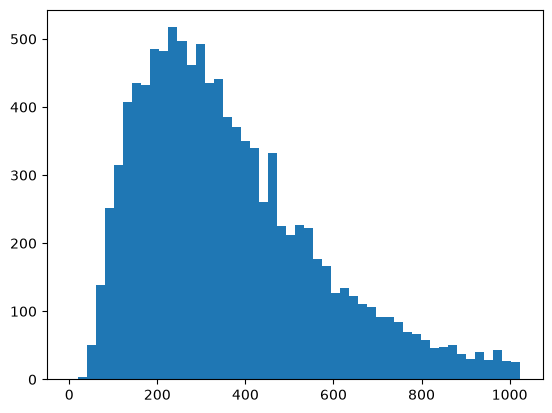

In [12]:
from tqdm.notebook import tqdm, trange

text_lengths = np.zeros(bunch.target.shape)
for idx, (text, label) in enumerate(tqdm(zip(bunch.data, bunch.target), desc="Tokenizing", total=len(bunch.target))): 

    # here we will tokenize a bit differently, in order to create same length vectors and masks
    # we need the tokenized outputs to all be the same length for speeding up computation
    encoded_example = tokenizer(text, return_tensors='pt')

    text_lengths[idx] = len(encoded_example.input_ids[0])

plt.hist(text_lengths, range=(0,1024), bins=50)
plt.show()

__________

<a id="tiny_bert"></a>

# TinyBERT: Modest Hardware Example for Sentiment 
Well 20- news groups did not have the huge performance gains that we wanted. Perhaps we should try a dataset with fewer tokens and a simpler task: sentiment prediction. Let's pull some additional examples from: https://mccormickml.com/2019/07/22/BERT-fine-tuning/ 

Hugging face offers an open source trained model for Tiny-BERT (posted by authors) that is accesisble using PyTorch: https://huggingface.co/prajjwal1/bert-tiny

We will use the datasets package to load the IMdB sentiment dataset. It contains text from movie reviewers with a positive or negative sentiment to the text only. The dataset will be saved in the following format: 

```python
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
```


In [35]:
import torch

from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline
from tqdm.notebook import tqdm, trange

from datasets import load_dataset

print(f"Torch: {torch.__version__}")
print(f"MPS: {torch.backends.mps.is_available()}") # able to use Apple Metal Performance Shaders (MPS)? 
device = torch.device("mps")

# Load the sentiment dataset
dataset = load_dataset("imdb")

dataset

Torch: 2.13.0
MPS: True


Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at /Users/eclarson/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Thu Aug 27 15:22:26 2026).


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [36]:
def show_stats(data_in):
    labels = np.array([x['label'] for x in data_in])
    counts = np.bincount(labels)
    print(f'Found unique labels {np.unique(labels)} with counts {counts}')
    
show_stats(dataset['train'])
show_stats(dataset['test'])


Found unique labels [0 1] with counts [12500 12500]
Found unique labels [0 1] with counts [12500 12500]


In [37]:
from transformers import BertTokenizer, BertForSequenceClassification #Trainer, TrainingArguments

# Load a pre-trained BERT model and tokenizer
# model_name = 'bert-base-uncased' # larger model from above
model_name = 'prajjwal1/bert-tiny' #smaller model, nice for running on a laptop
tokenizer = BertTokenizer.from_pretrained(model_name, do_lower_case=True)


Tokenizing:   0%|          | 0/25000 [00:00<?, ?it/s]

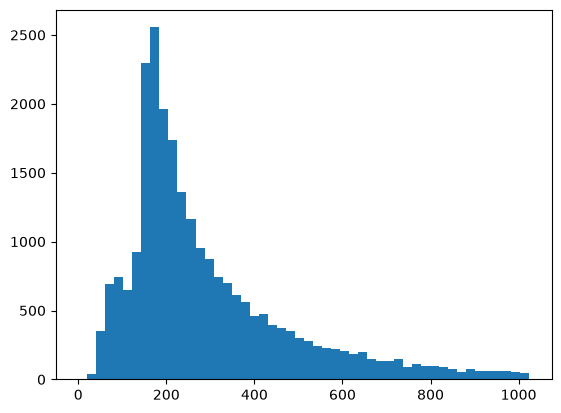

In [38]:

n = len(dataset['train'])
text_lengths = np.zeros((n,1))
for idx, data_row in enumerate(tqdm(dataset['train'], desc="Tokenizing", total=n)): 

    # here we will tokenize a bit differently, in order to create same length vectors and masks
    # we need the tokenized outputs to all be the same length for speeding up computation
    encoded_example = tokenizer(data_row['text'], return_tensors='pt')

    text_lengths[idx] = len(encoded_example.input_ids[0])

plt.hist(text_lengths, range=(0,1024), bins=50)
plt.show()

In [39]:
# Try to update this with better Data Loading:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

# Tokenize data efficiently with batching
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Format dataset for PyTorch tensors
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Create high-performance PyTorch DataLoaders
train_loader = DataLoader(tokenized_datasets["train"], shuffle=True, batch_size=BATCH_SIZE, num_workers=2, pin_memory_device="mps")
test_loader = DataLoader(tokenized_datasets["test"], batch_size=BATCH_SIZE, num_workers=2)

train_data = next(iter(train_loader)) #(input_ids, mask, token_type, label)
train_data

{'labels': tensor([1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
         0, 1, 1, 0, 0, 1, 1, 0]),
 'input_ids': tensor([[  101,  2269,  1997,  ...,     0,     0,     0],
         [  101,  1037,  6919,  ...,     0,     0,     0],
         [  101,  2096,  3666,  ...,  1029,  1026,   102],
         ...,
         [  101,  2023,  2565,  ...,     0,     0,     0],
         [  101,  1045,  2228,  ...,  1037,  2844,   102],
         [  101,  2023,  3185,  ...,  6570, 27562,   102]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]])}

In [41]:
model = BertForSequenceClassification.from_pretrained(model_name, 
                                                      num_labels=2,
                                                      output_hidden_states=False,
                                                      output_attentions = False
                                                     )

model = model.to(device)

model

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were 

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-1): 2 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm): LayerNorm((128,), e

```
==== Embedding Layer ====

bert.embeddings.word_embeddings.weight                  (30522, 128)
bert.embeddings.position_embeddings.weight                (512, 128)
bert.embeddings.token_type_embeddings.weight                (2, 128)
bert.embeddings.LayerNorm.weight                              (128,)
bert.embeddings.LayerNorm.bias                                (128,)

==== First Transformer ====

bert.encoder.layer.0.attention.self.query.weight          (128, 128)
bert.encoder.layer.0.attention.self.query.bias                (128,)
bert.encoder.layer.0.attention.self.key.weight            (128, 128)
bert.encoder.layer.0.attention.self.key.bias                  (128,)
bert.encoder.layer.0.attention.self.value.weight          (128, 128)
bert.encoder.layer.0.attention.self.value.bias                (128,)
bert.encoder.layer.0.attention.output.dense.weight        (128, 128)
bert.encoder.layer.0.attention.output.dense.bias              (128,)
bert.encoder.layer.0.attention.output.LayerNorm.weight        (128,)
bert.encoder.layer.0.attention.output.LayerNorm.bias          (128,)
bert.encoder.layer.0.intermediate.dense.weight            (512, 128)
bert.encoder.layer.0.intermediate.dense.bias                  (512,)
bert.encoder.layer.0.output.dense.weight                  (128, 512)
bert.encoder.layer.0.output.dense.bias                        (128,)
bert.encoder.layer.0.output.LayerNorm.weight                  (128,)
bert.encoder.layer.0.output.LayerNorm.bias                    (128,)

==== Output Layer ====

bert.pooler.dense.weight                                  (128, 128)
bert.pooler.dense.bias                                        (128,)
dropout                                                       (128,)
classifier.weight                                           (2, 128)
classifier.bias                                                 (2,)
```

In [42]:
# setup some tracking
history = {}
history['val_loss'] = []
history['train_loss'] = []

from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import LinearLR
from transformers import get_linear_schedule_with_warmup


if True:
    # train all parameters? 
    train_params = model.parameters()
else:
    #only train certain layers in the encoder? 
    train_params = []

    # only train the final layer of BERT
    # in our example, the final layer was called 'classifier', as shown in the summary above
    # unfreeze additional weights for fine tuning
    for param in model.parameters():
        param.requires_grad = False
    
    for layer_val in [-1,-2,-3]:
        for param in model.bert.encoder.layer[layer_val].parameters():
            train_params.extend(param)
            param.requires_grad = True
    
    #train entire bert encoder (not the embeddings)
    for layer in model.bert.encoder.layer:
        for param in layer.parameters():
            param.requires_grad = True
            train_params.extend(param)
    
    for param in model.bert.pooler.parameters():
        param.requires_grad = True
        train_params.extend(param)
    
    for param in model.classifier.parameters():
        param.requires_grad = True
        train_params.extend(param)
    

TOTAL_EPOCHS = 50 
total_steps = len(train_loader) * TOTAL_EPOCHS

optimizer = AdamW(train_params,
                  lr = 2e-5, 
                  eps = 1e-8 
                )

scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps = 500, # changed this to have some warming cycles, might need more
                                            num_training_steps = total_steps)

# scheduler = LinearLR(
#     optimizer, start_factor=1.0, end_factor=0.1, total_iters=total_steps
# )

print(f'Setup optimizer, training in {total_steps} steps with batch size of {BATCH_SIZE} for {TOTAL_EPOCHS} epochs')


Setup optimizer, training in 39100 steps with batch size of 32 for 50 epochs


In [47]:

train_size = len(train_loader)
eval_size = len(test_loader)

# setup a nice progress bar (tracking epochs), and keep a reference to it for showing validation loss
with trange(TOTAL_EPOCHS, desc="Epoch") as pbar:
    for epoch in pbar:
        # set model to training mode (i.e., use dropout and other training specific operations)
        model.train()
        total_loss = 0.0
        # do one epoch of training
        for batch in tqdm(train_loader, desc=f"Training {epoch}", total=train_size+1, leave=False):
            
            # send batch to MPS and separate for the model
            
            input_ids = batch["input_ids"].to(device)
            input_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            model.zero_grad()
            
            # because we give the labels, loss is also calculated
            output = model(input_ids, 
                           token_type_ids=None, 
                           attention_mask=input_mask, 
                           labels=labels)
    
            # back propagation
            loss = output.loss
            loss.backward() # register loss and perform gradient calculations
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step() # use gradients in optimizer
            scheduler.step() 
            

            # keep track of train loss
            total_loss += output.loss.item() * BATCH_SIZE
            
            #NOTE: could also accumulate gradient here to artificially expand batch size, 
            # and extend time between optimizer updates 

        total_loss = total_loss / train_size
        history['train_loss'].append(total_loss)
        
        # at end of epoch, report the evaluation
        model.eval()  # Set model to evaluation mode
        total_loss = 0.0
    
        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"Evaluating {epoch}", total=eval_size, leave=False):
                input_ids = batch["input_ids"].to(device)
                input_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
            
                output = model(input_ids,  token_type_ids=None, attention_mask=input_mask, labels=labels)
                # calculate the total loff for the batch (per item)
                total_loss += output.loss.item() * BATCH_SIZE
            # after iterating through all, divide by total number of samples
            total_loss = total_loss / eval_size
            history['val_loss'].append(total_loss)
        # print the eval loss in the progress bar for the epochs
        pbar.set_postfix(loss=f"{total_loss:.2f}")


Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Training 0:   0%|          | 0/783 [00:00<?, ?it/s]

Evaluating 0:   0%|          | 0/782 [00:00<?, ?it/s]

Training 1:   0%|          | 0/783 [00:00<?, ?it/s]

Evaluating 1:   0%|          | 0/782 [00:00<?, ?it/s]

...

Evaluating 47:   0%|          | 0/782 [00:00<?, ?it/s]

Training 48:   0%|          | 0/783 [00:00<?, ?it/s]

Evaluating 48:   0%|          | 0/782 [00:00<?, ?it/s]

Training 49:   0%|          | 0/783 [00:00<?, ?it/s]

Evaluating 49:   0%|          | 0/782 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/782 [00:00<?, ?it/s]

Evaluation Accuracy: 0.81784


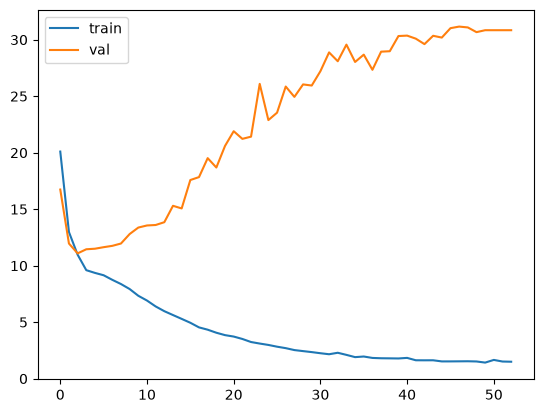

In [49]:
all_preds = []
all_labels = []

model.eval() # set model to evalaution mode (no dropout, etc.)

# run the evaluation without tracking gradient operations
with torch.no_grad():
    for batch in tqdm(test_loader,desc="Evaluating", total=eval_size):
        
        input_ids = batch["input_ids"].to(device)
        input_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
            
        
        output = model(input_ids, token_type_ids=None, attention_mask=input_mask, labels=None)

        # save these model outputs as numpy arrays.
        # 1. We need to detach the tensors from the computation graph
        # 2. then copy the tensor over to the cpu (from the GPU)
        # 3. then convert to numpy
        # 4. save this numpy vector in a list of other vectors
        # we will stack the vectors from the list into one big numpy vector later on
        all_preds.append(  output.logits.detach().cpu().numpy() )
        all_labels.append( labels.cpu().numpy() )

from sklearn.metrics import accuracy_score

# combine the individual batched outputs and argmax for the predictions

# stack lable array into vector of class index, [0, 5, 19, ... , 12, 13]
labels_array = np.hstack(all_labels)
# stack each prediction into matrix where row=[net outpu array] and col=[each class probaability]
# take argmax across each netowrk output (row) to collapse these into a vector of int classes [1, 5, 19, ... , 11, 13]
preds_array = np.argmax(np.vstack(all_preds), axis=1)

# now that the preds and labels are in a similar format, we can compare with sklearn metrics
print("Evaluation Accuracy:", accuracy_score(labels_array, preds_array))

plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.legend()
plt.show()